In [1]:
from sklearn.datasets import fetch_openml

X, y = fetch_openml('mnist_784', version=1,
    return_X_y=True)

X = X.values
y = y.astype(int).values

In [2]:
print("X shape: ", X.shape)
print("y shape: ", y.shape)

X shape:  (70000, 784)
y shape:  (70000,)


In [3]:
# Normalize the data to be between -1 and 1
X = ((X/255)-0.5)*2

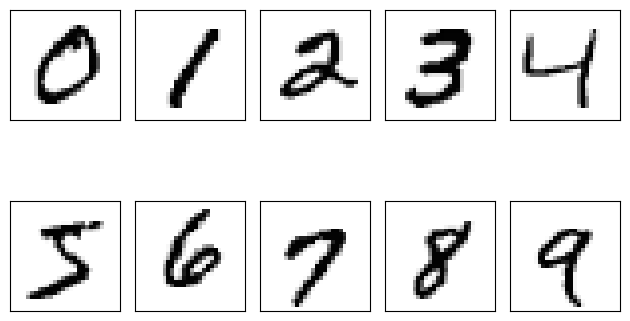

In [4]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(nrows=2, ncols=5,
    sharex=True, sharey=True)
ax = ax.flatten()
for i in range(10):
    img = X[y == i][0].reshape(28, 28)
    ax[i].imshow(img, cmap='Greys')
ax[0].set_xticks([])
ax[0].set_yticks([])
plt.tight_layout()
plt.show()

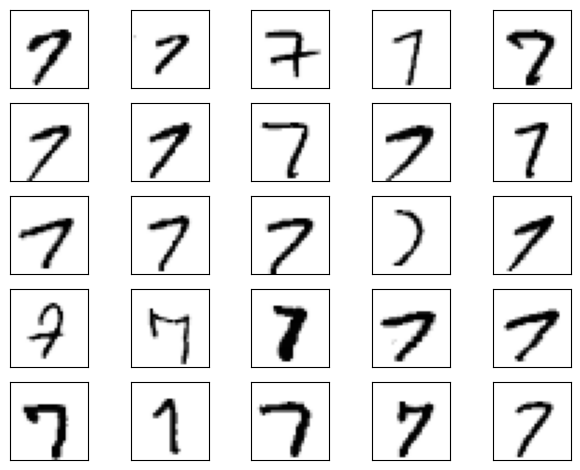

In [5]:
# visualize different handwritten of same digit

fig, ax = plt.subplots(nrows=5,
ncols=5,
sharex=True,
sharey=True)
ax = ax.flatten()
for i in range(25):
    img = X[y == 7][i].reshape(28, 28)
    ax[i].imshow(img, cmap='Greys')
ax[0].set_xticks([])
ax[0].set_yticks([])
plt.tight_layout()

In [6]:
from sklearn.model_selection import train_test_split

X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.2, 
    random_state=123, stratify=y
)

X_train, X_valid, y_train, y_valid = train_test_split(
    X_temp, y_temp, test_size=5000,
    random_state=123, stratify=y_temp
)

In [7]:
from mlp import NeuralNetMLP

model = NeuralNetMLP(num_features=28*28,
    num_hidden=50,
    num_classes=10)


In [8]:
import numpy as np

num_epoch = 50
mini_batch_size = 100

def generate_mini_batch(X, y, mini_batch_size):
    indicies = np.arange(X.shape[0])
    np.random.shuffle(indicies)

    for start_idx in range(0, indicies.shape[0] - mini_batch_size + 1, mini_batch_size):
        batch_index = indicies[start_idx:start_idx+mini_batch_size]
        yield X[batch_index], y[batch_index]

In [9]:
def int_to_one_hot(y, num_classes):
    one_hot = np.zeros((y.shape[0], num_classes))
    one_hot[np.arange(y.shape[0]), y] = 1
    return one_hot

def mse_loss(y, predictions):
    targets = int_to_one_hot(y, num_classes=10)
    return np.mean((targets - predictions)**2)

def accuracy(targets, predictions):
    return np.mean(targets == predictions)

In [10]:
_, probas = model.forward(X_valid)
mse = mse_loss(y_valid, probas)
print("initial validation MSE: %.2f" % mse)

acc = accuracy(y_valid, np.argmax(probas, axis=1))
print("initial validation accuracy: %.2f" % acc)

initial validation MSE: 0.27
initial validation accuracy: 0.09


In [11]:
def compute_mse_and_accuracy(model, X, y):
    acc, mse = [], []
    mini_batches = generate_mini_batch(X, y, mini_batch_size)
    for i, (X_mini, y_mini) in enumerate(mini_batches):
        _, probas = model.forward(X_mini)
        mse.append(mse_loss(y_mini, probas))
        predicted_classes = np.argmax(probas, axis=1)
        acc.append(accuracy(y_mini, predicted_classes))
    return mse, acc

In [12]:
mse, acc = compute_mse_and_accuracy(model, X_valid, y_valid)
print("Validation MSE: %.2f" % np.mean(mse))
print("Validation accuracy: %.2f" % (np.mean(acc)*100))

Validation MSE: 0.27
Validation accuracy: 9.28


In [13]:
def train(model, X_train, y_train, X_valid, y_valid, num_epoch, mini_batch_size, learning_rate):
    train_loss, train_acc = [], []
    valid_acc = []

    for e in range(num_epoch):
        mini_batches = generate_mini_batch(X_train, y_train, mini_batch_size)

        for X_mini, y_mini in mini_batches:
            a_h, a_out = model.forward(X_mini)

            d_loss__d_w_h, d_loss__d_b_h, \
            d_loss_d_w_out, d_loss_d_h_out = \
                model.backward(X_mini, y_mini, a_h, a_out)
            
            model.w_h -= learning_rate * d_loss__d_w_h
            model.b_h -= learning_rate * d_loss__d_b_h
            model.w_out -= learning_rate * d_loss_d_w_out
            model.b_out -= learning_rate * d_loss_d_h_out

        epoch_train_mse, epoch_train_acc = compute_mse_and_accuracy(model, X_train, y_train)
        epoch_valid_mse, epoch_valid_acc = compute_mse_and_accuracy(model, X_valid, y_valid)

        train_loss.append(np.mean(epoch_train_mse))
        train_acc.append(np.mean(epoch_train_acc))
        valid_acc.append(np.mean(epoch_valid_acc))

        print(f'Epoch: {e+1:03d}/{num_epoch:03d} '
             f'| Train MSE: {train_loss[-1]:.2f} '
             f'| Train Acc: {train_acc[-1]*100:.2f}% '
             f'| Valid Acc: {valid_acc[-1]*100:.2f}%')


    return train_loss, train_acc, valid_acc

In [14]:
train_loss, train_acc, valid_acc = train(model, X_train, y_train, X_valid, y_valid, num_epoch=50, mini_batch_size=100, learning_rate=0.001)

print("Final training accuracy: %.2f%%" % (np.mean(train_acc)*100))
print("Final validation accuracy: %.2f%%" % (np.mean(valid_acc)*100))


Epoch: 001/050 | Train MSE: 0.07 | Train Acc: 57.78% | Valid Acc: 57.68%
Epoch: 002/050 | Train MSE: 0.05 | Train Acc: 75.62% | Valid Acc: 74.82%
Epoch: 003/050 | Train MSE: 0.04 | Train Acc: 82.48% | Valid Acc: 81.96%
Epoch: 004/050 | Train MSE: 0.03 | Train Acc: 84.80% | Valid Acc: 84.34%
Epoch: 005/050 | Train MSE: 0.03 | Train Acc: 86.70% | Valid Acc: 86.30%
Epoch: 006/050 | Train MSE: 0.03 | Train Acc: 87.69% | Valid Acc: 87.20%
Epoch: 007/050 | Train MSE: 0.02 | Train Acc: 88.49% | Valid Acc: 88.08%
Epoch: 008/050 | Train MSE: 0.02 | Train Acc: 89.16% | Valid Acc: 89.02%
Epoch: 009/050 | Train MSE: 0.02 | Train Acc: 89.59% | Valid Acc: 89.46%
Epoch: 010/050 | Train MSE: 0.02 | Train Acc: 89.83% | Valid Acc: 89.58%
Epoch: 011/050 | Train MSE: 0.02 | Train Acc: 90.22% | Valid Acc: 90.06%
Epoch: 012/050 | Train MSE: 0.02 | Train Acc: 90.46% | Valid Acc: 90.46%
Epoch: 013/050 | Train MSE: 0.02 | Train Acc: 90.71% | Valid Acc: 90.76%
Epoch: 014/050 | Train MSE: 0.02 | Train Acc: 90.94

Text(0, 0.5, 'Loss')

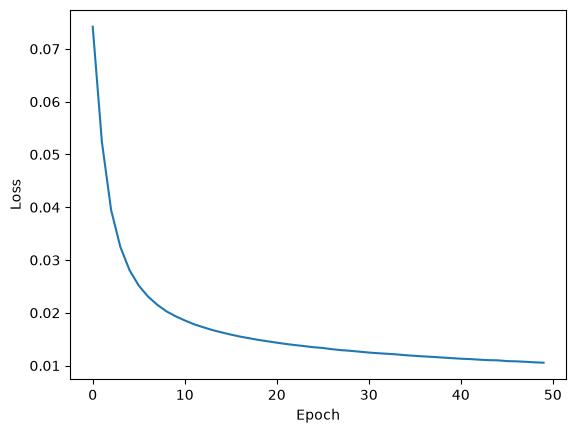

In [15]:
import matplotlib.pyplot as plt

plt.plot(range(num_epoch), train_loss)
plt.xlabel('Epoch')
plt.ylabel('Loss')

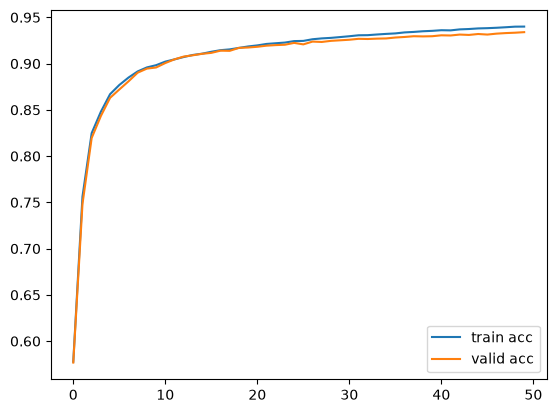

In [16]:
plt.plot(range(len(train_acc)), train_acc)
plt.plot(range(len(valid_acc)), valid_acc)
plt.legend(['train acc', 'valid acc'])
plt.show()

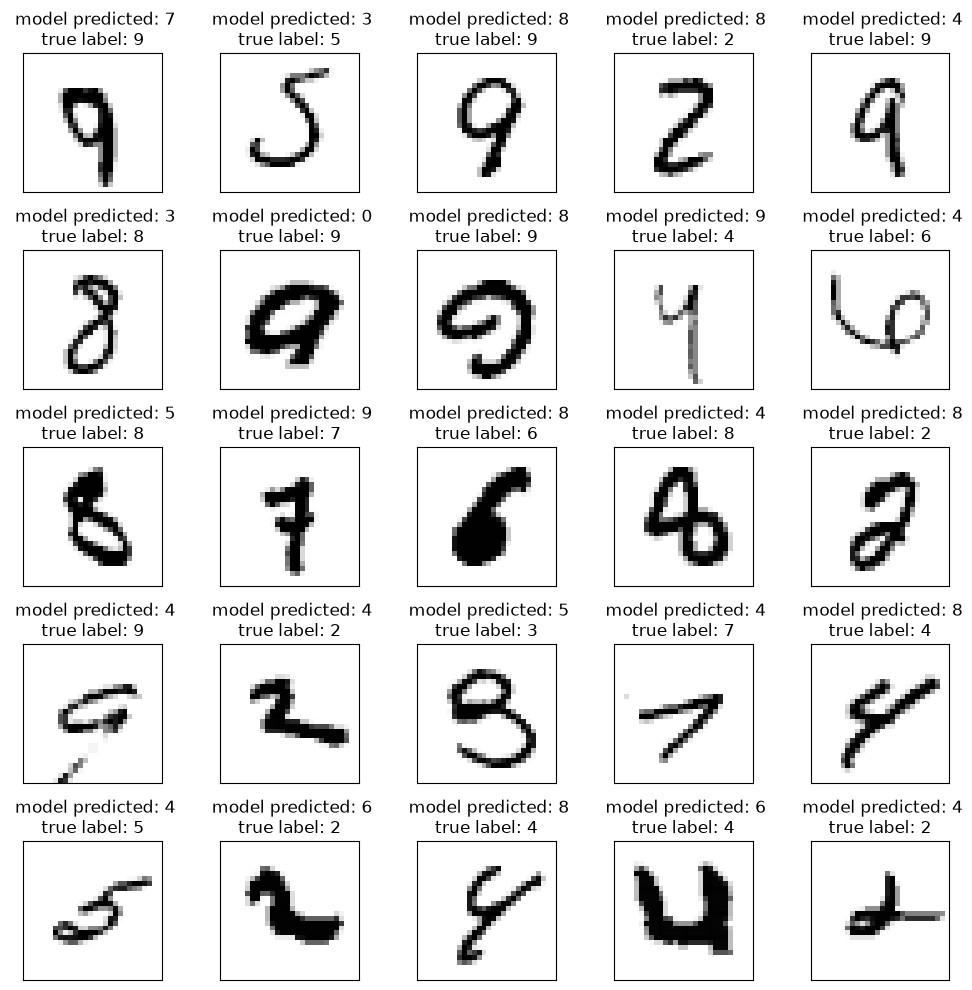

In [26]:
# misclassification visualization

X_test_suite, y_test_suite = X_test[:1000], y_test[:1000]
_, probas = model.forward(X_test_suite)
predicted_classes = np.argmax(probas, axis=1)

miscl_img = X_test_suite[y_test_suite != predicted_classes]
y_false_label = predicted_classes[y_test_suite != predicted_classes]
y_correct_label = y_test_suite[y_test_suite != predicted_classes]

fig, ax = plt.subplots(nrows=5, ncols=5,
    sharex=True, sharey=True, figsize=(10, 10))

ax = ax.flatten()

for i in range(25):
    img = miscl_img[i].reshape(28, 28)
    ax[i].imshow(img, cmap='Greys', interpolation='nearest')
    ax[i].set_xticks([])
    ax[i].set_yticks([])
    ax[i].set_title(f' model predicted: {y_false_label[i]}\n'
                    f'true label: {y_correct_label[i]}')

plt.tight_layout()
plt.show()
